# **ASSIGNMENT-7 Regularized Regression Models**

Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

Load Dataset

In [3]:
data = load_diabetes(as_frame=True)
df = data.frame

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Define Features and Target

In [4]:
X = df.drop('target', axis=1)
y = df['target']

X.shape, y.shape

((442, 10), (442,))

Train Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Linear Regression

In [8]:
lin = LinearRegression()
lin.fit(X_train, y_train)

pred_lin = lin.predict(X_test)

rmse_lin = np.sqrt(mean_squared_error(y_test, pred_lin))
r2_lin = r2_score(y_test, pred_lin)

print("RMSE:", rmse_lin)
print("R2 Score:", r2_lin)

RMSE: 53.85344583676593
R2 Score: 0.4526027629719195


Ridge Regression

In [10]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

pred_ridge = ridge.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_ridge))
r2_ridge = r2_score(y_test, pred_ridge)

print("Ridge RMSE:", rmse_ridge)
print("Ridge R2 Score:", r2_ridge)

Ridge RMSE: 55.47446204180109
Ridge R2 Score: 0.41915292635986556


Lasso Regression

In [11]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

pred_lasso = lasso.predict(X_test)

rmse_lasso = np.sqrt(mean_squared_error(y_test, pred_lasso))
r2_lasso = r2_score(y_test, pred_lasso)

print("Lasso RMSE:", rmse_lasso)
print("Lasso R2 Score:", r2_lasso)

Lasso RMSE: 53.65220765436038
Lasso R2 Score: 0.45668611945806237


ElasticNet Regression

In [12]:
elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)
elastic.fit(X_train, y_train)

pred_elastic = elastic.predict(X_test)

rmse_elastic = np.sqrt(mean_squared_error(y_test, pred_elastic))
r2_elastic = r2_score(y_test, pred_elastic)

print("ElasticNet RMSE:", rmse_elastic)
print("ElasticNet R2 Score:", r2_elastic)

ElasticNet RMSE: 57.606473086497914
ElasticNet R2 Score: 0.37364841571505814


Compare All Models Together

In [13]:
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso", "ElasticNet"],
    "RMSE": [rmse_lin, rmse_ridge, rmse_lasso, rmse_elastic],
    "R2 Score": [r2_lin, r2_ridge, r2_lasso, r2_elastic]
})

results

,Model,RMSE,R2 Score
0,Linear,53.853446,0.452603
1,Ridge,55.474462,0.419153
2,Lasso,53.652208,0.456686
3,ElasticNet,57.606473,0.373648


Compare Coefficients

In [14]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Linear': lin.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_,
    'ElasticNet': elastic.coef_
})

coef_df

,Feature,Linear,Ridge,Lasso,ElasticNet
0,age,37.904021,45.367377,35.347451,41.385384
1,sex,-241.964362,-76.666086,-231.906664,-43.389860
2,bmi,542.428759,291.338832,551.303242,219.917202
3,bp,347.703844,198.995817,341.313469,154.182517
4,s1,-931.488846,-0.530310,-483.567140,13.827544
5,s2,518.062277,-28.577050,165.990532,-5.305924
6,s3,163.419983,-144.511905,-25.834899,-115.773546
7,s4,275.317902,119.260066,216.875803,103.224221
8,s5,736.198859,230.221608,566.815003,179.472215
9,s6,48.670657,112.149830,49.702475,100.040552


Plot Coefficients

<Figure size 1200x600 with 0 Axes>

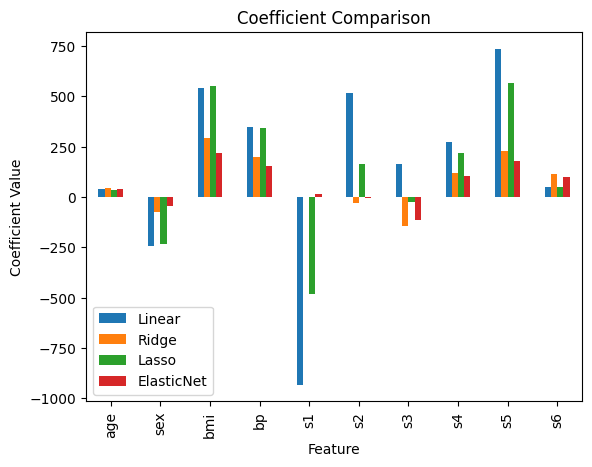

In [15]:
plt.figure(figsize=(12,6))
coef_df.set_index('Feature').plot(kind='bar')
plt.title("Coefficient Comparison")
plt.ylabel("Coefficient Value")
plt.show()

Best Model

In [16]:
results.sort_values(by="R2 Score", ascending=False)

,Model,RMSE,R2 Score
2,Lasso,53.652208,0.456686
0,Linear,53.853446,0.452603
1,Ridge,55.474462,0.419153
3,ElasticNet,57.606473,0.373648


# ***CONCLUSION***

In this experiment, we implemented Linear Regression, Ridge, Lasso, and ElasticNet on the Diabetes dataset to compare their performance and understand the effect of regularization.
Linear Regression served as the baseline model, but it may suffer from overfitting when features are highly correlated. Ridge Regression applied L2 regularization, which reduced the magnitude of coefficients and improved model generalization. Lasso Regression used L1 regularization, which shrinks coefficients and sets some of them to zero, performing automatic feature selection. ElasticNet combined both L1 and L2 regularization, providing a balance between Ridge and Lasso.
From the results, regularized models performed better or similarly to Linear Regression while reducing overfitting. Lasso helped identify important features by eliminating less significant ones, and ElasticNet provided stable and balanced performance.
Therefore, regularization techniques such as Ridge, Lasso, and ElasticNet improve model performance, reduce overfitting, and help build more reliable machine learning models.